# Ticket Exploratory Analysis · Swiss Life

This Python notebook describes the complete ticket dataset: structure, completeness,
distributions, dates, elapsed time to closure, assignments, and text. The included results
were calculated using **all 20,000 records**, without sampling.

## Run this version alongside the existing analysis

Keep this notebook inside the `analysis_en` folder at the root of your repository.
Reuse `jira_first_20000_requested_fields_synthetic.json` from the repository root; there
is no need to copy the dataset or change the existing analysis files.

From the repository root, start JupyterLab:

```bash
jupyter lab analysis_en/Ticket_Exploratory_Analysis_Swiss_Life.ipynb
```

Select **Python 3**, then **Run → Run All Cells**. If the existing notebook already runs,
use the same Python environment. The accompanying `README.md` explains installation
and how to commit this folder. You can also open this notebook in VS Code with the
Python and Jupyter extensions and select your Python environment.

The configuration cell finds the dataset in this folder or its parent. Set `DATA_FILE`
to an explicit path if needed. Results are saved inside `analysis_en/results/` when the
folder is placed as described. Rerunning updates these English exports; it does not change
the source JSON. Top-10 previews do **not** limit the rows used in the analysis or exports.

## Interpretation rules

The supplied challenge guidance, included as `challenge_guidance.md`, states that the
data are **synthetic** and **Priority, Urgency, and Impact were randomly sampled,
independently of each other and of ticket content**. Their frequencies describe the
synthetic generator, not actual business severity. Recorded services may be incorrect
or generic, and some closing comments provide little reusable information.

This is descriptive analysis, **not model training or retraining**. It does not calculate
classification accuracy or evaluate the separate 20-ticket challenge file, which was not
provided. Service mentions and historical routing are not verified ground truth.

## 1. Configuration

`DATA_FILE` identifies the input JSON. `OUTPUT_DIR` identifies the English results folder.
Summary tables and charts are exported by default. Detailed ticket and comment exports
are optional. Package versions are recorded for reproducibility.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import importlib.metadata
import json
import platform
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

NOTEBOOK_NAME = "Ticket_Exploratory_Analysis_Swiss_Life.ipynb"
ANALYSIS_DIR = Path.cwd()
# VS Code may start the kernel in the repository root rather than the notebook folder.
if (ANALYSIS_DIR / "analysis_en" / NOTEBOOK_NAME).is_file():
    ANALYSIS_DIR = ANALYSIS_DIR / "analysis_en"

DATA_FILE = Path("jira_first_20000_requested_fields_synthetic.json")
OUTPUT_DIR = ANALYSIS_DIR / "results"
EXPORT = True
EXPORT_DETAILED_DATA = False
TOP_N = 10

if not DATA_FILE.is_file() and str(DATA_FILE) == "jira_first_20000_requested_fields_synthetic.json":
    search_folders = [ANALYSIS_DIR, ANALYSIS_DIR.parent, Path.cwd(), Path.cwd() / "data", Path.cwd() / "upload"]
    candidates = [folder / name for folder in search_folders for name in [
        "jira_first_20000_requested_fields_synthetic.json",
        "01-jira_first_20000_requested_fields_synthetic.json",
    ]]
    DATA_FILE = next((path for path in candidates if path.is_file()), DATA_FILE)
if not DATA_FILE.is_file():
    raise FileNotFoundError("JSON not found. Place it in the repository root or set DATA_FILE to its path.")

pd.set_option("display.max_columns", 20)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")
sns.set_theme(style="whitegrid", palette="colorblind", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
BLUE, GREEN, ORANGE = "#2364AA", "#27856B", "#D88728"
tables = {}

def show_table(name, table, limit=None):
    tables[name] = table.copy()
    display(table if limit is None else table.head(limit))

def show_figure(name, fig):
    fig.tight_layout()
    if EXPORT:
        (OUTPUT_DIR / "charts").mkdir(parents=True, exist_ok=True)
        fig.savefig(OUTPUT_DIR / "charts" / f"{name}.png", dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def shorten(value, length=140):
    text = json.dumps(value, ensure_ascii=False) if isinstance(value, (list, dict)) else str(value)
    return text if len(text) <= length else text[:length - 1] + "…"

versions = {package: importlib.metadata.version(package) for package in ["pandas", "numpy", "matplotlib", "seaborn"]}
print("Input file:", DATA_FILE.name)
print("Python:", platform.python_version(), "| Packages:", versions)

Input file: jira_first_20000_requested_fields_synthetic.json
Python: 3.12.14 | Packages: {'pandas': '2.2.3', 'numpy': '2.3.5', 'matplotlib': '3.10.8', 'seaborn': '0.13.2'}


## 2. Load every record and validate the schema

The actual file is a JSON list with **16 fields per ticket**. It does not contain
`Issue ID`, `Issue Key`, `Request type`, `Severity`, `Due date`, or `Linked issues`.
A local row identifier is created later; it is **not a Jira key**.
`raw` retains the original values. Missing values are not replaced with invented data.

In [2]:
content = DATA_FILE.read_bytes()
input_sha256 = hashlib.sha256(content).hexdigest()
records = json.loads(content.decode("utf-8-sig"))
if not isinstance(records, list) or not records or not all(isinstance(record, dict) for record in records):
    raise ValueError("Expected a nonempty JSON list of ticket objects.")

FIELDS = [
    "Work type", "Summary", "Description", "Affected Business or IT Services",
    "Business Entity", "Service Team(s)", "Reporter", "Assignee", "Priority",
    "Urgency", "Impact", "Created date", "Status", "Resolution", "Resolution date", "All Comments",
]
LIST_FIELDS = ["Affected Business or IT Services", "Business Entity", "Service Team(s)", "All Comments"]
raw = pd.DataFrame(records)
missing_columns = sorted(set(FIELDS) - set(raw.columns))
if missing_columns:
    raise ValueError(f"Missing expected columns: {missing_columns}. Review the schema before continuing.")
N = len(raw)
print(f"Tickets loaded: {N:,} | Fields: {raw.shape[1]} | Size: {len(content) / 1024**2:.2f} MiB")
print("Input SHA-256:", input_sha256)
print("Additional fields:", sorted(set(raw.columns) - set(FIELDS)))
display(raw.head(3))

Tickets loaded: 20,000 | Fields: 16 | Size: 23.81 MiB
Input SHA-256: 6f3ad42cbe5095d6541c47095258c233554c1da46fbc47c529735667876f8844
Additional fields: []


,Work type,Summary,Description,Affected Business or IT Services,Business Entity,Service Team(s),Reporter,Assignee,Priority,Urgency,Impact,Created date,Status,Resolution,Resolution date,All Comments
0,Service Request,New license requested for Tax Reporting,A new user requires a license for Tax Reporting to support an operational activity. The request ...,[Tax Reporting],[Nordics],[Tax & Reporting],luca.rinaldi@intcom.com,oliver.varga@intcom.com,low,low,low,2026-03-03 19:36,done,done,2026-03-16 11:51,[nina.baker@intcom.com: Initial triage assigned to Tax & Reporting and reviewed against the serv...
1,Service Request,New license requested for Outlook & Email,A new user requires a license for Outlook & Email to support an operational activity. The reques...,[Outlook & Email],[Switzerland],[Enterprise Applications],maia.berg@intcom.com,jack.martin@intcom.com,low,medium,lowest,2026-06-07 07:38,done,cannot reproduce,2026-06-09 13:30,[louis.belov@intcom.com: Initial triage assigned to Enterprise Applications and reviewed against...
2,Service Request,Incorrect incident title for service request in Portfolio Accounting,"The submitted title suggests an incident affecting Portfolio Accounting, but the actual request ...",[Portfolio Accounting],[Switzerland],[Investment Operations],info@extcom_19.com,tania.gupta@intcom.com,lowest,low,medium,2026-06-23 14:00,done,clarification,2026-06-28 09:07,[marta.marchand@intcom.com: Initial triage assigned to Investment Operations and reviewed agains...


## 3. Field dictionary and real examples

`Status` describes the workflow state. `Resolution` describes the closing outcome:
a ticket with status `done` may have resolution `cancelled` or `cannot reproduce`.
**Resolution `done` alone does not prove that the requester validated the solution.**
Up to three distinct examples are shown per field. Long examples are shortened for display.

In [3]:
definitions = {
    "Work type": ("Work category: Incident or Service Request.", "Initial classification that the agent can suggest."),
    "Summary": ("Short ticket title.", "Text input interpreted together with Description."),
    "Description": ("Explanation of the issue or request.", "Main input for classification and retrieval of similar cases."),
    "Affected Business or IT Services": ("List of services recorded as affected.", "Related to team and catalog criticality; the label may be incorrect."),
    "Business Entity": ("List of affected business entities or regions.", "Geographic context; not equivalent to impact or urgency."),
    "Service Team(s)": ("List of teams assigned to the ticket.", "Observed routing history; not necessarily the correct assignment."),
    "Reporter": ("Person or address that submitted the request.", "Describes the source; not necessarily the affected person."),
    "Assignee": ("Person assigned responsibility for the ticket.", "Related to the team; ticket count does not measure productivity."),
    "Priority": ("Recorded ticket priority.", "Random in this dataset; not a valid severity training label."),
    "Urgency": ("Recorded urgency: how much delay could be tolerated.", "Random in this dataset and independent of the ticket text."),
    "Impact": ("Recorded impact: the scope of the consequences.", "Random here; distinct from service criticality."),
    "Created date": ("Ticket creation date and time.", "Start of the elapsed interval to closure; no time zone is supplied."),
    "Status": ("Observed current state: open, in progress, or done.", "Separates open and closed tickets in this snapshot."),
    "Resolution": ("Closing outcome: done, cancelled, clarification, or cannot reproduce.", "Interpret with Status and Resolution date; this is not detailed solution text."),
    "Resolution date": ("Recorded closure or resolution date and time.", "Together with Created date, measures elapsed calendar time."),
    "All Comments": ("List of comments, usually prefixed with the author.", "May contain solution steps, generic statements, or information added after intake."),
}
dictionary_rows = []
for field in FIELDS:
    examples = list(dict.fromkeys(json.dumps(record.get(field), ensure_ascii=False) for record in records))[:3]
    meaning, relationship = definitions[field]
    row = {"field": field, "meaning": meaning, "agent_relationship": relationship}
    for index in range(3):
        row[f"example_{index + 1}"] = shorten(json.loads(examples[index]), 95) if index < len(examples) else "No further distinct value"
    dictionary_rows.append(row)
dictionary = pd.DataFrame(dictionary_rows)
show_table("field_dictionary", dictionary[["field", "meaning", "agent_relationship"]])
show_table("field_examples", dictionary[["field", "example_1", "example_2", "example_3"]])

,field,meaning,agent_relationship
0,Work type,Work category: Incident or Service Request.,Initial classification that the agent can suggest.
1,Summary,Short ticket title.,Text input interpreted together with Description.
2,Description,Explanation of the issue or request.,Main input for classification and retrieval of similar cases.
3,Affected Business or IT Services,List of services recorded as affected.,Related to team and catalog criticality; the label may be incorrect.
4,Business Entity,List of affected business entities or regions.,Geographic context; not equivalent to impact or urgency.
5,Service Team(s),List of teams assigned to the ticket.,Observed routing history; not necessarily the correct assignment.
6,Reporter,Person or address that submitted the request.,Describes the source; not necessarily the affected person.
7,Assignee,Person assigned responsibility for the ticket.,Related to the team; ticket count does not measure productivity.
8,Priority,Recorded ticket priority.,Random in this dataset; not a valid severity training label.
9,Urgency,Recorded urgency: how much delay could be tolerated.,Random in this dataset and independent of the ticket text.


,field,example_1,example_2,example_3
0,Work type,Service Request,Incident,No further distinct value
1,Summary,New license requested for Tax Reporting,New license requested for Outlook & Email,Incorrect incident title for service request in Portfolio Accounting
2,Description,A new user requires a license for Tax Reporting to support an operational activity. The reques…,A new user requires a license for Outlook & Email to support an operational activity. The requ…,"The submitted title suggests an incident affecting Portfolio Accounting, but the actual reques…"
3,Affected Business or IT Services,"[""Tax Reporting""]","[""Outlook & Email""]","[""Portfolio Accounting""]"
4,Business Entity,"[""Nordics""]","[""Switzerland""]","[""Germany""]"
5,Service Team(s),"[""Tax & Reporting""]","[""Enterprise Applications""]","[""Investment Operations""]"
6,Reporter,luca.rinaldi@intcom.com,maia.berg@intcom.com,info@extcom_19.com
7,Assignee,oliver.varga@intcom.com,jack.martin@intcom.com,tania.gupta@intcom.com
8,Priority,low,lowest,medium
9,Urgency,low,medium,lowest


## 4. Completeness and data types

Missing keys, `null`, blank strings, and empty containers are counted separately.
Completeness uses **all tickets as its denominator**; it does not establish correctness.
An empty resolution on an open ticket may be expected.

,field,types,missing_keys,null,blank_text,empty_container,populated,completeness_pct,distinct_values_including_null
0,Work type,str,0,0,0,0,20000,100.00,2
1,Summary,str,0,0,0,0,20000,100.00,173
2,Description,str,0,0,0,0,20000,100.00,173
3,Affected Business or IT Services,list,0,0,0,0,20000,100.00,20
4,Business Entity,list,0,0,0,0,20000,100.00,5
5,Service Team(s),list,0,0,0,0,20000,100.00,11
6,Reporter,str,0,0,0,0,20000,100.00,92
7,Assignee,str,0,0,0,0,20000,100.00,30
8,Priority,str,0,0,0,0,20000,100.00,5
9,Urgency,str,0,0,0,0,20000,100.00,5


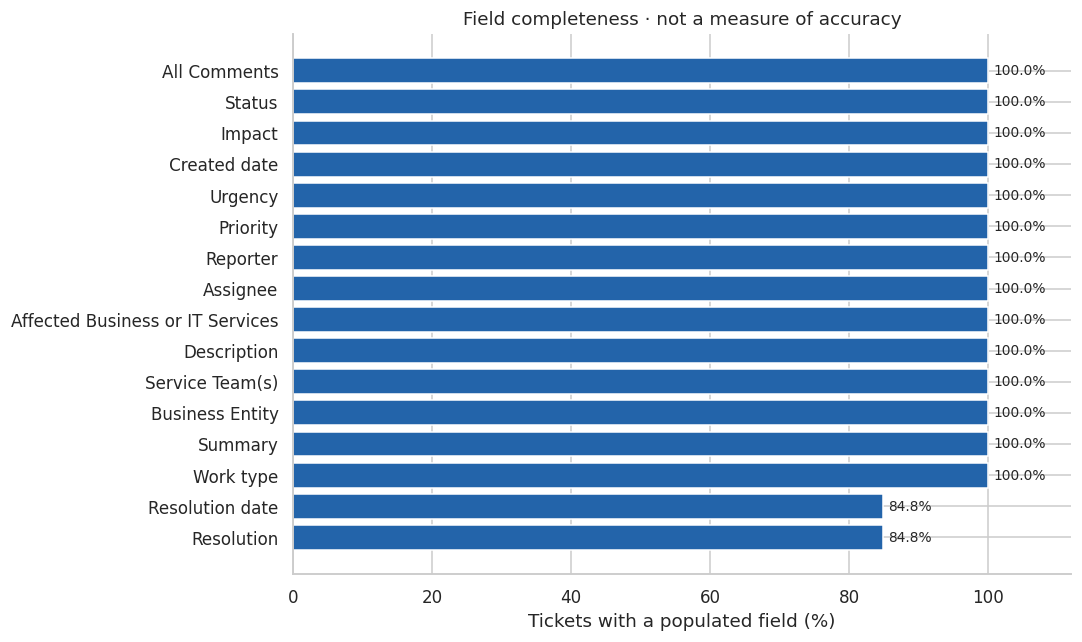

In [4]:
def cell_state(record, field):
    if field not in record:
        return "missing_key"
    value = record[field]
    if value is None:
        return "null"
    if isinstance(value, str) and not value.strip():
        return "blank_text"
    if isinstance(value, (list, dict)) and not value:
        return "empty_container"
    return "populated"

profile_rows = []
for field in raw.columns:
    states = pd.Series([cell_state(record, field) for record in records]).value_counts()
    distinct_values = len({json.dumps(record[field], sort_keys=True, ensure_ascii=False) for record in records if field in record})
    profile_rows.append({
        "field": field,
        "types": ", ".join(sorted({type(record[field]).__name__ for record in records if field in record})),
        "missing_keys": int(states.get("missing_key", 0)),
        "null": int(states.get("null", 0)),
        "blank_text": int(states.get("blank_text", 0)),
        "empty_container": int(states.get("empty_container", 0)),
        "populated": int(states.get("populated", 0)),
        "completeness_pct": 100 * states.get("populated", 0) / N,
        "distinct_values_including_null": distinct_values,
    })
profile = pd.DataFrame(profile_rows)
show_table("field_quality", profile)
fig, ax = plt.subplots(figsize=(10, 6))
ordered = profile.sort_values("completeness_pct", ascending=True)
ax.barh(ordered["field"], ordered["completeness_pct"], color=BLUE)
ax.set(xlim=(0, 112), xlabel="Tickets with a populated field (%)", title="Field completeness · not a measure of accuracy")
for index, value in enumerate(ordered["completeness_pct"]):
    ax.text(value + 0.8, index, f"{value:.1f}%", va="center", fontsize=9)
show_figure("01_completeness", fig)

## 5. Prepare one ticket table and separate relationship tables

Services, entities, teams, and comments are expanded separately. Expanding all lists at
once could multiply rows and distort counts. `analysis_row_id` follows the original file
order and changes if that order changes; it is not a stable source-system identifier.

Dates use the supplied `YYYY-MM-DD HH:MM` format. No time zone is provided, so the values
remain **time-zone-naive**, without an invented UTC conversion. Intervals represent
calendar time, not working hours, analyst effort, or SLA compliance.

In [5]:
df = raw.copy(deep=True)
df.insert(0, "analysis_row_id", np.arange(1, N + 1))
# Normalize only the working copy; keep the source JSON unchanged.
for field in set(FIELDS) - set(LIST_FIELDS):
    df[field] = df[field].astype("string").str.strip().replace("", pd.NA)
for field in ["Status", "Resolution", "Priority", "Urgency", "Impact"]:
    df[field] = df[field].str.casefold()
for field in LIST_FIELDS:
    malformed = raw[field].map(lambda value: not (
        value is None or isinstance(value, list) and all(isinstance(item, str) for item in value)
    ))
    if malformed.any():
        raise ValueError(f"{field}: expected lists of strings. Review rows with other types.")
    df[field] = raw[field].map(lambda value: [item.strip() for item in value if item.strip()] if isinstance(value, list) else [])

df["created_at"] = pd.to_datetime(df["Created date"], format="%Y-%m-%d %H:%M", errors="coerce")
df["resolved_at"] = pd.to_datetime(df["Resolution date"], format="%Y-%m-%d %H:%M", errors="coerce")
df["is_closed"] = df["Status"].eq("done").fillna(False)
df["n_comments"] = df["All Comments"].map(len)
df["days_to_closure"] = (df["resolved_at"] - df["created_at"]).dt.total_seconds() / 86400

def relationship_table(field):
    result = df[["analysis_row_id", field]].explode(field).dropna(subset=[field])
    return result.drop_duplicates(["analysis_row_id", field]).reset_index(drop=True)

services = relationship_table("Affected Business or IT Services")
entities = relationship_table("Business Entity")
teams = relationship_table("Service Team(s)")
list_structure = pd.DataFrame([
    {"field": field, "min_items": df[field].map(len).min(), "max_items": df[field].map(len).max(),
     "tickets_with_multiple_items": int(df[field].map(len).gt(1).sum()), "total_items": df[field].map(len).sum()}
    for field in LIST_FIELDS
])
show_table("list_structure", list_structure)

,field,min_items,max_items,tickets_with_multiple_items,total_items
0,Affected Business or IT Services,1,1,0,20000
1,Business Entity,1,1,0,20000
2,Service Team(s),1,1,0,20000
3,All Comments,1,5,15885,52845


## 6. Ticket volume, work type, and status

These proportions describe the supplied snapshot. They are not agent success rates.
Each distribution uses all tickets as its denominator, including missing values when present.

,metric,value
0,Tickets,20000
1,Original fields,16
2,Closed: Status = done,16969
3,Open or in progress,3031
4,Recorded resolution = done,4236
5,Distinct recorded services,20
6,Distinct entities,5
7,Distinct teams,11
8,Distinct assignees,30
9,Distinct reporters,92


,value,tickets,ticket_pct
0,Incident,16000,80.00
1,Service Request,4000,20.00


,value,tickets,ticket_pct
0,open,967,4.83
1,in progress,2064,10.32
2,done,16969,84.84


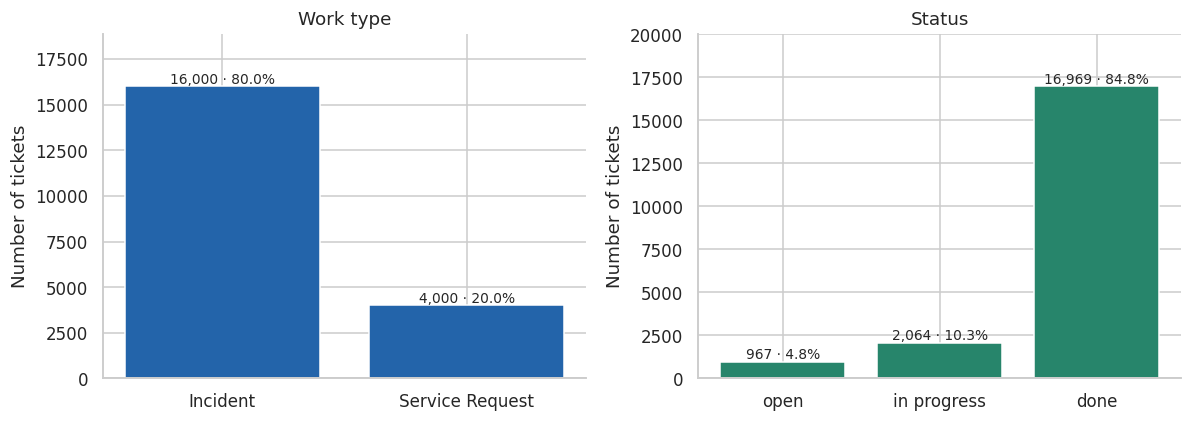

In [6]:
def frequency(series, order=None, denominator=None):
    counts = series.astype("string").fillna("(missing)").value_counts()
    if order is not None:
        remaining = [value for value in counts.index if value not in order]
        counts = counts.reindex(list(order) + remaining, fill_value=0)
    denominator = len(series) if denominator is None else denominator
    return pd.DataFrame({"value": counts.index, "tickets": counts.values,
                         "ticket_pct": 100 * counts.values / denominator if denominator else np.nan})

overview = pd.DataFrame([
    ("Tickets", N), ("Original fields", len(raw.columns)),
    ("Closed: Status = done", int(df["is_closed"].sum())),
    ("Open or in progress", int(df["Status"].isin(["open", "in progress"]).sum())),
    ("Recorded resolution = done", int(df["Resolution"].eq("done").sum())),
    ("Distinct recorded services", services.iloc[:, 1].nunique()),
    ("Distinct entities", entities.iloc[:, 1].nunique()),
    ("Distinct teams", teams.iloc[:, 1].nunique()),
    ("Distinct assignees", df["Assignee"].nunique()),
    ("Distinct reporters", df["Reporter"].nunique()),
    ("Comments", int(df["n_comments"].sum())),
], columns=["metric", "value"])
show_table("overview", overview)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, field, order in zip(axes, ["Work type", "Status"], [None, ["open", "in progress", "done"]]):
    table = frequency(df[field], order)
    show_table("frequency_" + field.lower().replace(" ", "_"), table)
    ax.bar(table["value"], table["tickets"], color=BLUE if field == "Work type" else GREEN)
    ax.set(title=field, ylabel="Number of tickets")
    ax.margins(y=0.18)
    for index, row in table.iterrows():
        ax.text(index, row["tickets"], f'{row["tickets"]:,} · {row["ticket_pct"]:.1f}%', ha="center", va="bottom", fontsize=9)
show_figure("02_work_type_and_status", fig)

## 7. Services, entities, and catalog criticality

Each table counts each **ticket–category pair** once. A ticket with multiple services
would contribute to multiple categories, so percentages could sum to more than 100%.
Every ticket in this particular file has one recorded service, entity, and team.

Criticality comes from the supplied challenge guidance and is applied to the **recorded
service**, which may be mislabeled. It does not validate the affected service or replace
urgency, impact, or priority. `Emailed Support Tickets` is worth reviewing as a generic label.

,value,tickets,ticket_pct
0,Emailed Support Tickets,5423,27.11
1,Outlook & Email,805,4.03
2,Trade Matching,801,4.00
3,Trading Platform,800,4.00
4,Fund Pricing,799,4.00
5,SimCorp Dimension,797,3.98
6,Corporate Actions,780,3.90
7,Securities Settlement,778,3.89
8,Risk & Compliance Monitoring,777,3.88
9,Portfolio Accounting,774,3.87


,value,tickets,ticket_pct
0,Luxembourg,4113,20.57
1,Nordics,4015,20.07
2,Switzerland,3976,19.88
3,Germany,3965,19.82
4,France,3931,19.66


,value,tickets,ticket_pct
0,At least one recorded critical service,10759,53.80
1,Only recorded noncritical services,9241,46.20


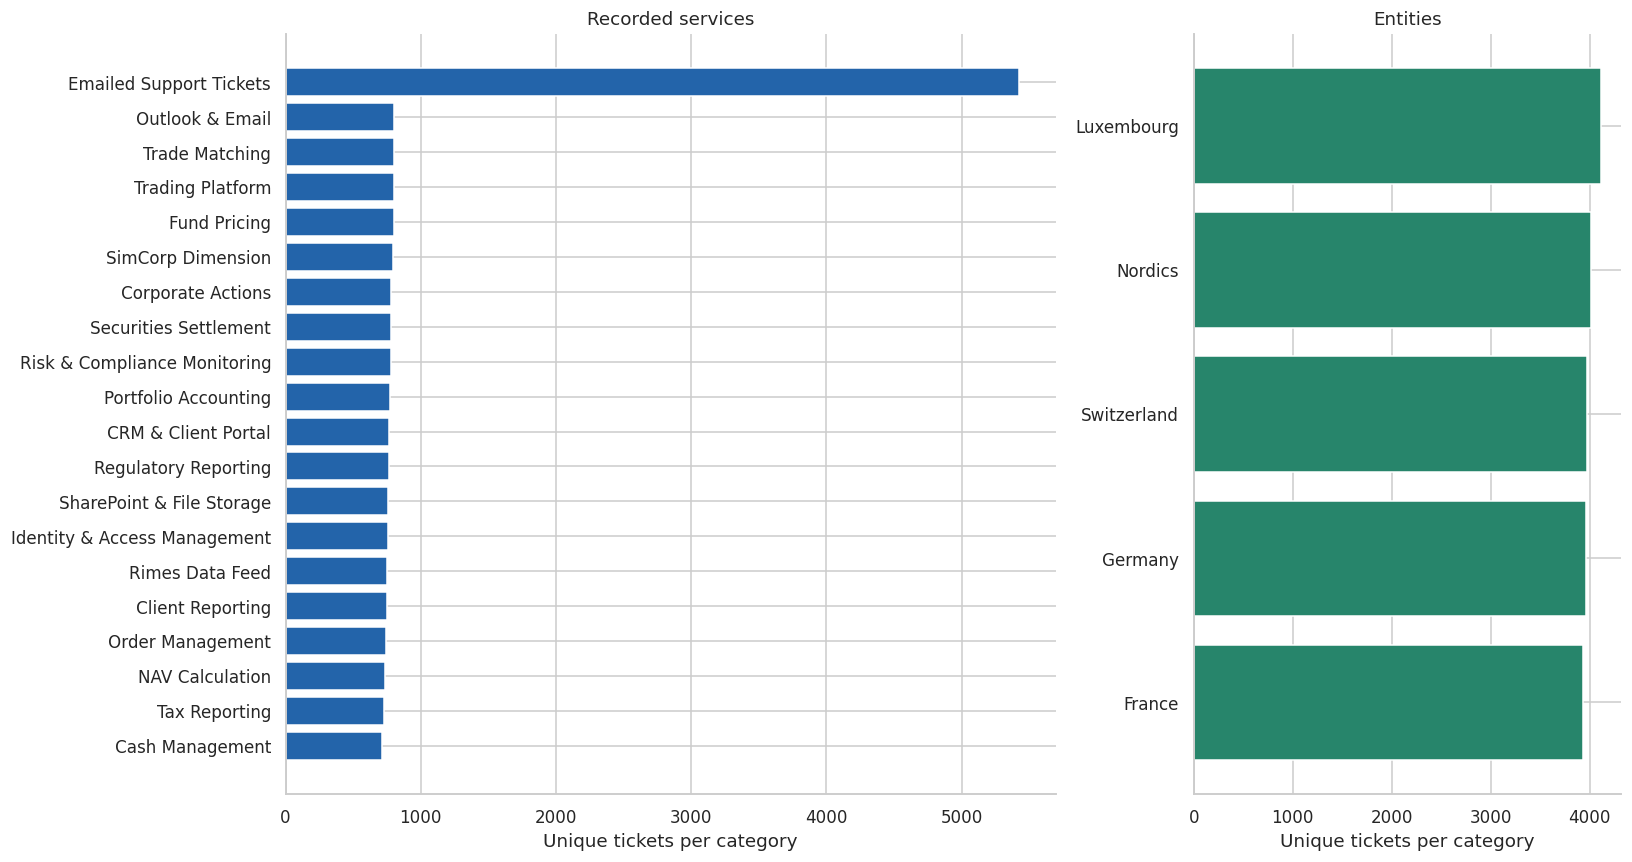

In [7]:
CRITICAL_SERVICES = {
    "Trading Platform", "Order Management", "Trade Matching", "Securities Settlement",
    "Corporate Actions", "Fund Pricing", "NAV Calculation", "Portfolio Accounting",
    "Cash Management", "Risk & Compliance Monitoring", "Regulatory Reporting",
    "SimCorp Dimension", "Rimes Data Feed", "Client Reporting",
}
NONCRITICAL_SERVICES = {
    "Tax Reporting", "CRM & Client Portal", "Identity & Access Management",
    "SharePoint & File Storage", "Outlook & Email", "Emailed Support Tickets",
}
CATALOG = sorted(CRITICAL_SERVICES | NONCRITICAL_SERVICES)
service_frequency = frequency(services.iloc[:, 1], denominator=N)
entity_frequency = frequency(entities.iloc[:, 1], denominator=N)
show_table("frequency_services", service_frequency)
show_table("frequency_entities", entity_frequency)

def catalog_criticality(items):
    if not items:
        return "No service recorded"
    if any(item not in CRITICAL_SERVICES | NONCRITICAL_SERVICES for item in items):
        return "At least one service outside the catalog"
    return "At least one recorded critical service" if any(item in CRITICAL_SERVICES for item in items) else "Only recorded noncritical services"

df["recorded_catalog_criticality"] = df["Affected Business or IT Services"].map(catalog_criticality)
show_table("recorded_catalog_criticality", frequency(df["recorded_catalog_criticality"]))

fig, axes = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={"width_ratios": [1.8, 1]})
for ax, table, title in [(axes[0], service_frequency, "Recorded services"), (axes[1], entity_frequency, "Entities")]:
    ordered = table.iloc[::-1]
    ax.barh(ordered["value"], ordered["tickets"], color=BLUE if ax is axes[0] else GREEN)
    ax.set(title=title, xlabel="Unique tickets per category")
show_figure("03_services_and_entities", fig)

## 8. Teams, assignees, reporters, and observed routing

Assignment counts do not measure concurrent workload, effort, availability, or productivity.
A frequent route is an **observed assignment**, not a validated recommendation.
Service-to-team and service-to-entity comparisons use only tickets with exactly one value
in both fields, avoiding invented pairings between multi-valued lists.

Assignee: showing the top 10 values; all values are included in the export.
Reporter: showing the top 10 values; all values are included in the export.
Routing coverage with one service and one team: 20,000/20,000 tickets.


,value,tickets,ticket_pct
0,Service Desk,5423,27.11
1,Enterprise Applications,3116,15.58
2,Investment Operations,2375,11.88
3,Securities Operations,1558,7.79
4,Risk & Controls,1541,7.71
5,Valuation & Pricing,1536,7.68
6,Client Services,1514,7.57
7,Market Data Services,751,3.75
8,Trading Support,739,3.69
9,Tax & Reporting,731,3.65


,value,tickets,ticket_pct
0,maya.kerr@intcom.com,718,3.59
1,henry.patel@intcom.com,712,3.56
2,vicky.chen@intcom.com,709,3.54
3,nora.leclerc@intcom.com,709,3.54
4,leo.zimmer@intcom.com,703,3.52
5,gina.muller@intcom.com,691,3.46
6,adam.paul@intcom.com,689,3.44
7,zoe.peters@intcom.com,685,3.42
8,tania.gupta@intcom.com,683,3.42
9,david.kim@intcom.com,681,3.40


,value,tickets,ticket_pct
0,sa_accounting@intcom.com,3512,17.56
1,sa_securities@intcom.com,3401,17.00
2,info@extcom_05.com,231,1.16
3,info@extcom_12.com,228,1.14
4,info@extcom_28.com,220,1.10
5,info@extcom_16.com,214,1.07
6,info@extcom_08.com,212,1.06
7,info@extcom_18.com,208,1.04
8,info@extcom_14.com,206,1.03
9,info@extcom_30.com,204,1.02


,value,tickets,ticket_pct
0,intcom.com,14033,70.17
1,extcom_05.com,231,1.16
2,extcom_12.com,228,1.14
3,extcom_28.com,220,1.10
4,extcom_16.com,214,1.07
5,extcom_08.com,212,1.06
6,extcom_18.com,208,1.04
7,extcom_14.com,206,1.03
8,extcom_30.com,204,1.02
9,extcom_25.com,204,1.02


,service,team,tickets,service_pct
0,CRM & Client Portal,Client Services,768,100.00
1,Cash Management,Treasury & Cash,716,100.00
2,Client Reporting,Client Services,746,100.00
3,Corporate Actions,Securities Operations,780,100.00
4,Emailed Support Tickets,Service Desk,5423,100.00
5,Fund Pricing,Valuation & Pricing,799,100.00
6,Identity & Access Management,Enterprise Applications,755,100.00
7,NAV Calculation,Valuation & Pricing,737,100.00
8,Order Management,Trading Support,739,100.00
9,Outlook & Email,Enterprise Applications,805,100.00


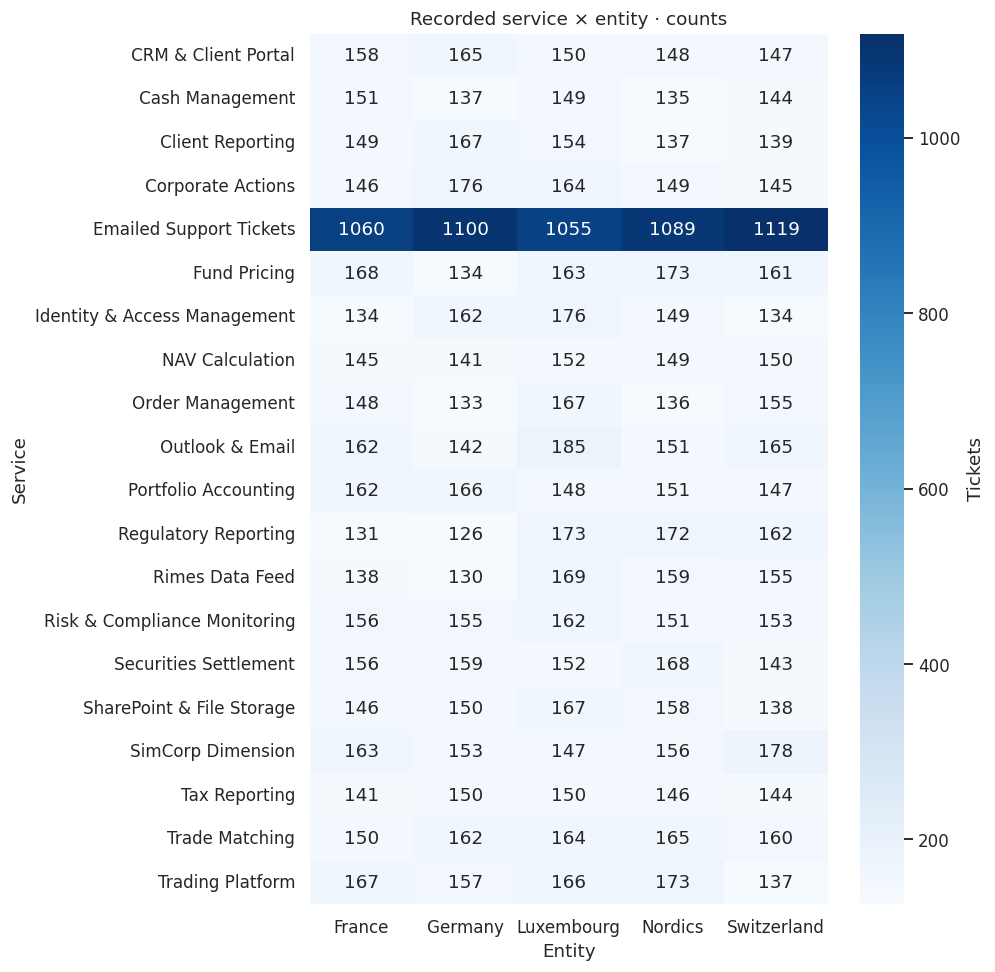

In [8]:
show_table("frequency_teams", frequency(teams.iloc[:, 1], denominator=N))
for field in ["Assignee", "Reporter"]:
    print(f"{field}: showing the top {TOP_N} values; all values are included in the export.")
    show_table("frequency_" + field.lower(), frequency(df[field]), limit=TOP_N)
df["reporter_domain"] = df["Reporter"].str.extract(r"@([^@\s]+)$", expand=False).str.casefold()
show_table("reporter_domains", frequency(df["reporter_domain"]), limit=TOP_N)

routing_mask = df["Affected Business or IT Services"].map(len).eq(1) & df["Service Team(s)"].map(len).eq(1)
routes = pd.DataFrame({
    "service": df.loc[routing_mask, "Affected Business or IT Services"].str[0],
    "team": df.loc[routing_mask, "Service Team(s)"].str[0],
})
all_routes = routes.groupby(["service", "team"]).size().rename("tickets").reset_index()
all_routes["service_pct"] = 100 * all_routes["tickets"] / all_routes.groupby("service")["tickets"].transform("sum")
print(f"Routing coverage with one service and one team: {routing_mask.sum():,}/{N:,} tickets.")
show_table("observed_routes", all_routes.sort_values(["service", "tickets"], ascending=[True, False]), limit=30)

entity_mask = df["Affected Business or IT Services"].map(len).eq(1) & df["Business Entity"].map(len).eq(1)
service_entity = pd.crosstab(
    df.loc[entity_mask, "Affected Business or IT Services"].str[0],
    df.loc[entity_mask, "Business Entity"].str[0],
)
tables["service_by_entity"] = service_entity.reset_index()
fig, ax = plt.subplots(figsize=(9, 9))
sns.heatmap(service_entity, cmap="Blues", annot=True, fmt="d", ax=ax, cbar_kws={"label": "Tickets"})
ax.set(title="Recorded service × entity · counts", xlabel="Entity", ylabel="Service")
show_figure("04_service_by_entity", fig)

## 9. Priority, urgency, and impact: random-label distributions

The challenge guidance states that these three fields are random. **Independent does
not mean uniform**: `lowest` can be far more common than `highest` without contradicting
that statement. The cross-tabulation below contains observed counts; **it is not the
priority decision matrix**.

The separate 20-ticket challenge derives priority from urgency and impact. Its guidance
uses urgency `Critical` and business descriptions of impact, whereas this dataset uses
`highest`, `high`, `medium`, `low`, and `lowest`. We do not invent a mapping between those
schemas or treat disagreements with the challenge matrix as labeling errors.

,value,tickets,ticket_pct
0,highest,384,1.92
1,high,1629,8.14
2,medium,1880,9.40
3,low,6070,30.35
4,lowest,10037,50.19


,value,tickets,ticket_pct
0,highest,379,1.90
1,high,1618,8.09
2,medium,2008,10.04
3,low,5979,29.89
4,lowest,10016,50.08


,value,tickets,ticket_pct
0,highest,376,1.88
1,high,1636,8.18
2,medium,1962,9.81
3,low,5962,29.81
4,lowest,10064,50.32


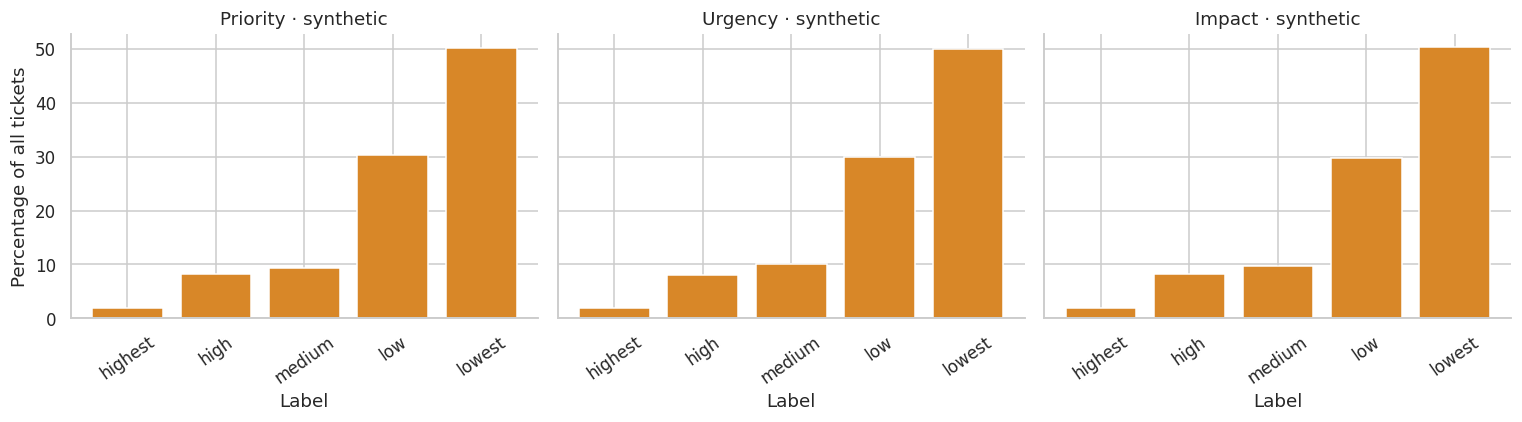

Impact,Urgency,highest,high,medium,low,lowest
0,highest,10,21,45,118,185
1,high,35,127,150,478,828
2,medium,44,157,188,642,977
3,low,110,503,588,1803,2975
4,lowest,177,828,991,2921,5099


In [9]:
LEVEL_ORDER = ["highest", "high", "medium", "low", "lowest"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, field in zip(axes, ["Priority", "Urgency", "Impact"]):
    table = frequency(df[field], LEVEL_ORDER)
    show_table("frequency_" + field.lower(), table)
    ax.bar(table["value"], table["ticket_pct"], color=ORANGE)
    ax.set(title=field + " · synthetic", xlabel="Label")
    ax.tick_params(axis="x", rotation=35)
axes[0].set_ylabel("Percentage of all tickets")
show_figure("05_random_labels", fig)
urgency_impact = pd.crosstab(df["Urgency"], df["Impact"]).reindex(index=LEVEL_ORDER, columns=LEVEL_ORDER, fill_value=0)
show_table("urgency_by_impact", urgency_impact.reset_index())

## 10. Date checks and closure consistency

These rules identify cases to review; they do not replace the Jira workflow definition.
Expected nulls are distinguished from supplied dates that cannot be parsed.
Cancelled or unreproducible tickets can legitimately be closed and have a resolution date.

In [10]:
invalid_creation = df["Created date"].notna() & df["created_at"].isna()
invalid_resolution = df["Resolution date"].notna() & df["resolved_at"].isna()
rules = {
    "Supplied creation date has an unrecognized format": invalid_creation,
    "Supplied closure date has an unrecognized format": invalid_resolution,
    "Missing creation date": df["Created date"].isna(),
    "Closure precedes creation": df["days_to_closure"].lt(0),
    "Status done without Resolution": df["is_closed"] & df["Resolution"].isna(),
    "Status done without a valid closure date": df["is_closed"] & df["resolved_at"].isna(),
    "Status other than done with Resolution": ~df["is_closed"] & df["Resolution"].notna(),
    "Status other than done with a closure date": ~df["is_closed"] & df["resolved_at"].notna(),
}
date_checks = pd.DataFrame([
    {"check": name, "tickets": int(mask.sum()), "ticket_pct": 100 * mask.sum() / N}
    for name, mask in rules.items()
])
show_table("date_and_status_checks", date_checks)
review_mask = pd.Series(False, index=df.index)
for mask in rules.values():
    review_mask |= mask.fillna(False)
tables["date_rows_to_review"] = df.loc[review_mask, ["analysis_row_id", "Status", "Resolution", "Created date", "Resolution date"]]
status_resolution = pd.crosstab(df["Status"].fillna("(missing)"), df["Resolution"].fillna("(no resolution)"))
show_table("status_by_resolution", status_resolution.reset_index())
show_table("frequency_resolution", frequency(df["Resolution"]))
print("Creation range:", df["created_at"].min(), "→", df["created_at"].max())
print("Recorded closure range:", df["resolved_at"].min(), "→", df["resolved_at"].max())
print("Tickets without a resolution:", df["Resolution"].isna().sum())

Creation range: 2026-01-01 00:00:00 → 2026-08-31 23:56:00
Recorded closure range: 2026-01-02 18:57:00 → 2026-09-21 08:51:00
Tickets without a resolution: 3031


,check,tickets,ticket_pct
0,Supplied creation date has an unrecognized format,0,0.00
1,Supplied closure date has an unrecognized format,0,0.00
2,Missing creation date,0,0.00
3,Closure precedes creation,0,0.00
4,Status done without Resolution,0,0.00
5,Status done without a valid closure date,0,0.00
6,Status other than done with Resolution,0,0.00
7,Status other than done with a closure date,0,0.00


Resolution,Status,(no resolution),cancelled,cannot reproduce,clarification,done
0,done,0,4168,4322,4243,4236
1,in progress,2064,0,0,0,0
2,open,967,0,0,0,0


,value,tickets,ticket_pct
0,cannot reproduce,4322,21.61
1,clarification,4243,21.21
2,done,4236,21.18
3,cancelled,4168,20.84
4,(missing),3031,15.15


## 11. Time distribution

Creation and recorded closure events are counted by month. A partial month cannot be
compared directly with a complete month. The extraction date is not documented: the
latest observed date is **not assumed to be a cutoff date**. These series do not
reconstruct a complete history of state changes, reopenings, or backlog.

,month,created,recorded_closures
0,2026-01,2509,1379
1,2026-02,2276,1936
2,2026-03,2551,2170
3,2026-04,2559,2125
4,2026-05,2591,2255
5,2026-06,2502,2089
6,2026-07,2479,2105
7,2026-08,2533,2171
8,2026-09,0,739


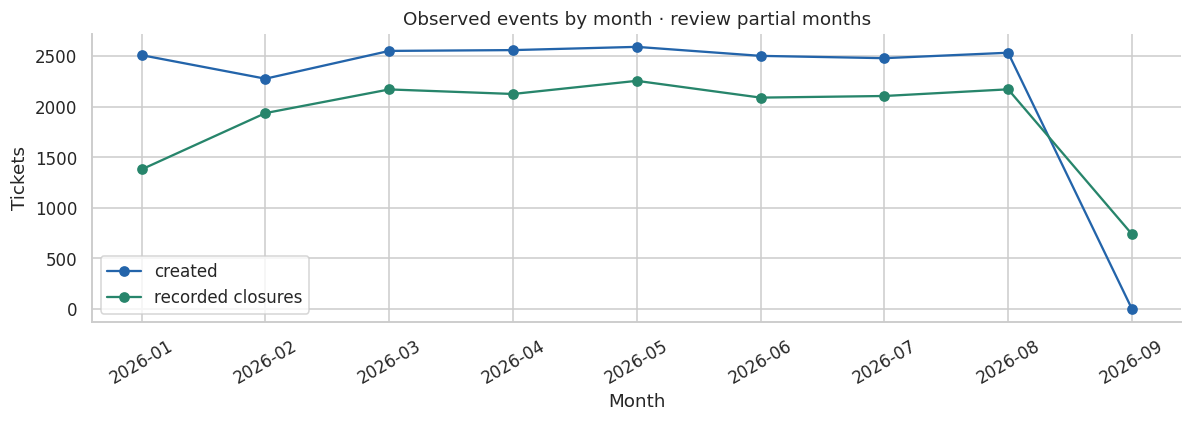

,creation_month,tickets,closed,closed_pct_in_snapshot
0,2026-01,2509,2152,85.77
1,2026-02,2276,1936,85.06
2,2026-03,2551,2140,83.89
3,2026-04,2559,2193,85.70
4,2026-05,2591,2176,83.98
5,2026-06,2502,2122,84.81
6,2026-07,2479,2110,85.11
7,2026-08,2533,2140,84.48


In [11]:
created_series = df["created_at"].dropna().dt.to_period("M").value_counts().sort_index()
closed_series = df.loc[df["is_closed"], "resolved_at"].dropna().dt.to_period("M").value_counts().sort_index()
monthly_volume = pd.concat([created_series.rename("created"), closed_series.rename("recorded_closures")], axis=1).fillna(0).astype(int).sort_index()
monthly_volume.index.name = "month"
monthly_table = monthly_volume.reset_index()
monthly_table["month"] = monthly_table["month"].astype(str)
show_table("monthly_volume", monthly_table)

fig, ax = plt.subplots(figsize=(11, 4))
for field, color in [("created", BLUE), ("recorded_closures", GREEN)]:
    ax.plot(monthly_table["month"], monthly_table[field], marker="o", label=field.replace("_", " "), color=color)
ax.set(title="Observed events by month · review partial months", xlabel="Month", ylabel="Tickets")
ax.tick_params(axis="x", rotation=30)
ax.legend()
show_figure("06_monthly_volume", fig)

cohorts = df.dropna(subset=["created_at"]).assign(creation_month=lambda frame: frame["created_at"].dt.to_period("M").astype(str))
cohorts = cohorts.groupby("creation_month").agg(tickets=("analysis_row_id", "size"), closed=("is_closed", "sum"))
cohorts["closed_pct_in_snapshot"] = 100 * cohorts["closed"] / cohorts["tickets"]
show_table("creation_cohorts", cohorts.reset_index())

## 12. Elapsed calendar time to closure

`Resolution date − Created date` is calculated only for tickets with `Status = done`,
two valid dates, and a nonnegative interval. All closing outcomes are included and also
reported separately. Open tickets are excluded **without replacing their time with zero**,
so the summary of closed tickets may have selection bias.

The median (P50) divides observed durations in half. P90 is the value at or below which
approximately 90% of those durations fall. These are **synthetic calendar-day intervals**,
not SLA measurements or evidence of the real performance of Swiss Life or the future agent.

Included tickets: 16,969/20,000; excluded: 3,031.


,statistic,days_except_count
0,count,"16,969.00"
1,mean,10.94
2,std,5.77
3,min,1.00
4,25%,5.97
5,50%,10.88
6,75%,15.94
7,90%,18.98
8,95%,19.97
9,max,21.00


,Resolution,tickets,mean_days,median_days,p90_days
1,cannot reproduce,4322,10.82,10.76,18.86
2,clarification,4243,10.97,10.97,19.02
3,done,4236,11.10,11.07,19.19
0,cancelled,4168,10.87,10.81,18.83


,Work type,tickets,mean_days,median_days,p90_days
0,Incident,13552,10.99,10.96,19.00
1,Service Request,3417,10.75,10.60,18.87


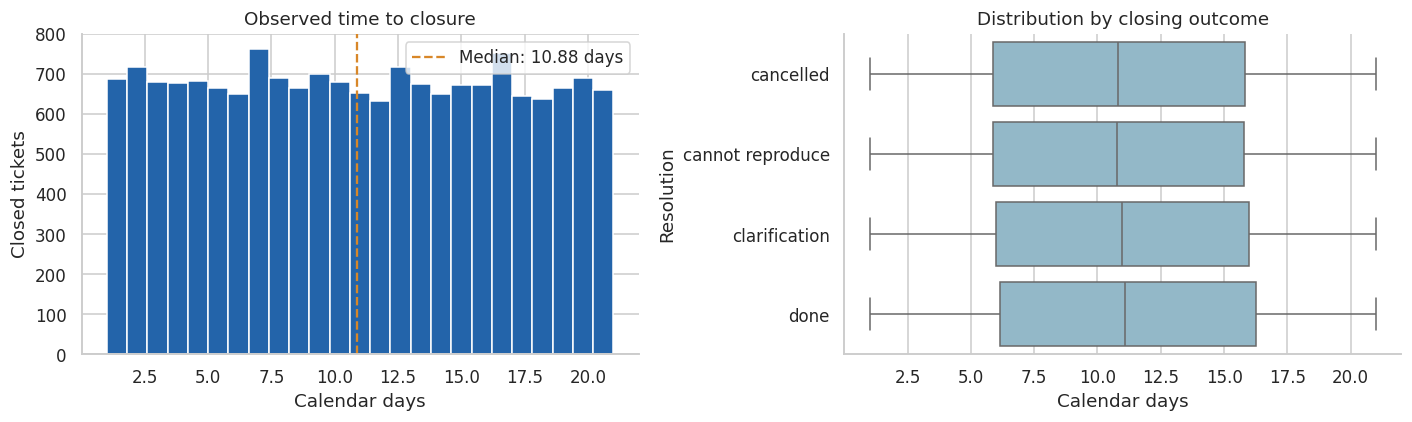

In [12]:
duration_mask = df["is_closed"] & df["created_at"].notna() & df["resolved_at"].notna() & df["days_to_closure"].ge(0)
valid_closed = df.loc[duration_mask].copy()
durations = valid_closed["days_to_closure"]
duration_statistics = durations.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]).rename_axis("statistic").reset_index(name="days_except_count")
show_table("time_to_closure_statistics", duration_statistics)
print(f"Included tickets: {len(valid_closed):,}/{N:,}; excluded: {N - len(valid_closed):,}.")

def duration_summary(field):
    return valid_closed.groupby(field, dropna=False)["days_to_closure"].agg(
        tickets="size", mean_days="mean", median_days="median", p90_days=lambda series: series.quantile(0.90)
    ).reset_index().sort_values("tickets", ascending=False)

for field, name in [("Resolution", "resolution"), ("Work type", "work_type")]:
    show_table("durations_by_" + name, duration_summary(field))
if len(valid_closed):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(durations, bins=25, color=BLUE, edgecolor="white")
    axes[0].axvline(durations.median(), color=ORANGE, linestyle="--", label=f"Median: {durations.median():.2f} days")
    axes[0].set(title="Observed time to closure", xlabel="Calendar days", ylabel="Closed tickets")
    axes[0].legend()
    outcome_order = sorted(valid_closed["Resolution"].dropna().unique())
    sns.boxplot(data=valid_closed, y="Resolution", x="days_to_closure", order=outcome_order, color="#8ABBD1", ax=axes[1])
    axes[1].set(title="Distribution by closing outcome", xlabel="Calendar days", ylabel="Resolution")
    show_figure("07_time_to_closure", fig)

## 13. Duplicate records and repeated text templates

A **complete duplicate** repeats every field of an object. A **repeated text template**
shares a title and description after case and whitespace normalization, even when dates,
people, status, or comments differ. Records are not automatically deleted.

A later random train/test split across nearly identical rows can cause information
leakage. Grouping the split by text template is a starting point; also review semantic
similarity and whether each input was available at prediction time.

In [13]:
canonical_records = pd.Series([json.dumps(record, sort_keys=True, ensure_ascii=False, separators=(",", ":")) for record in records])
complete_duplicates = int(canonical_records.duplicated().sum())

def normalize_text(value):
    return re.sub(r"\s+", " ", str(value).casefold()).strip() if pd.notna(value) else ""

normalized_pairs = [json.dumps([normalize_text(summary), normalize_text(description)], ensure_ascii=False)
                    for summary, description in zip(df["Summary"], df["Description"])]
df["text_template_id"] = [hashlib.sha256(pair.encode("utf-8")).hexdigest() for pair in normalized_pairs]
template_counts = df["text_template_id"].value_counts()
templates = df.groupby("text_template_id", sort=False).agg(
    tickets=("analysis_row_id", "size"), example_summary=("Summary", "first"), example_description=("Description", "first")
).reset_index().sort_values("tickets", ascending=False)
repetition = pd.DataFrame([
    ("Complete duplicates beyond the first occurrence", complete_duplicates),
    ("Distinct raw title-description pairs", len(raw[["Summary", "Description"]].drop_duplicates())),
    ("Distinct normalized text templates", len(template_counts)),
    ("Rows beyond the first example of each template", N - len(template_counts)),
    ("Tickets in templates that appear more than once", int(template_counts[template_counts.gt(1)].sum())),
], columns=["metric", "tickets_or_templates"])
show_table("text_repetition", repetition)
show_table("text_templates", templates, limit=TOP_N)

,metric,tickets_or_templates
0,Complete duplicates beyond the first occurrence,0
1,Distinct raw title-description pairs,173
2,Distinct normalized text templates,173
3,Rows beyond the first example of each template,19827
4,Tickets in templates that appear more than once,20000


,text_template_id,tickets,example_summary,example_description
98,834554e1f51ebf2240cdb264b2f40d60f69eb9f98f5b616eb6d731ea6beb88f9,4212,External email warning received for Emailed Support Tickets,A third party sent a warning regarding Emailed Support Tickets. The email references a delayed f...
11,a9482fe8b5f10fd9a705cdfbbe1c5e8a33a12fa9e4a58977293094e7a6ab5b76,1211,Email notification received for Emailed Support Tickets,An external party sent an email warning related to Emailed Support Tickets. The message referenc...
145,adc741c8ae13b36fc79b76865cd77b5ff03609e50295166a9717ec81b9f058de,434,Automated alert triggered for SimCorp Dimension,SimCorp Dimension generated an automated monitoring alert indicating an operational problem. The...
97,f42edf96c22c5349b8b3e1327a0cd774e485eebd680fddc467704b0a9a7fd64c,420,Automated alert triggered for Trading Platform,Trading Platform generated an automated monitoring alert indicating an operational problem. The ...
132,894c52f2bb3f80e16081032ea0be052455382909c471c649a13b4d7f951700cc,414,Automated alert triggered for Outlook & Email,Outlook & Email generated an automated monitoring alert indicating an operational problem. The l...
120,5613baab4ce007353a6e5ba3bb7b259a453686bfdf3a507723f706d60b8fc3b7,409,Automated alert triggered for Portfolio Accounting,Portfolio Accounting generated an automated monitoring alert indicating an operational problem. ...
133,655eb92b8bcb0f2a28e1ebd6d3582df6e9af21c8231c15567ba39f83ca7bd852,408,Automated alert triggered for Fund Pricing,Fund Pricing generated an automated monitoring alert indicating an operational problem. The log ...
108,d5a956a6deece75de42edee88df2437203d518cbec89b0131965254e25d3218f,407,Automated alert triggered for Trade Matching,Trade Matching generated an automated monitoring alert indicating an operational problem. The lo...
115,d8bf08a8b90c4cc751d892fa325115268bf515e0e5980ef71ad02a15b8bcc184,401,Automated alert triggered for Rimes Data Feed,Rimes Data Feed generated an automated monitoring alert indicating an operational problem. The l...
107,4d18d735ab769e0a7c2914717f61d53c76cc88e800e0838bafeae53599f548d0,393,Automated alert triggered for SharePoint & File Storage,SharePoint & File Storage generated an automated monitoring alert indicating an operational prob...


## 14. Descriptions and comments as knowledge material

This section measures text length, comment counts, and frequent phrases. An author
prefix is separated only when it resembles an email address followed by `:`. Individual
comment timestamps are absent, so first-response time and comment availability at ticket
creation cannot be determined.

The exact phrase `Problem fixed.`, a comment of at most eight words, and a `Resolution:`
prefix are **literal exploration signals**, not an automated judgment of solution quality.
Comment counts and affected-ticket counts use separate denominators.

Total comments: 52845 | Distinct bodies: 79


,statistic,summary_chars,description_chars,description_words,n_comments
0,count,"20,000.00","20,000.00","20,000.00","20,000.00"
1,mean,51.58,271.15,40.21,2.64
2,std,7.45,21.65,3.97,1.17
3,min,33.00,204.00,31.00,1.00
4,25%,45.00,271.00,37.00,2.00
5,50%,51.00,276.00,38.00,3.00
6,75%,59.00,279.00,44.00,4.00
7,max,76.00,315.00,47.00,5.00


,value,tickets,ticket_pct
0,1,4115,20.57
1,2,5232,26.16
2,3,5422,27.11
3,4,4155,20.77
4,5,1076,5.38


,text,comments,comment_pct
0,problem fixed.,5851,11.07
1,we validated the issue against emailed support tickets and checked whether it matched the expect...,3850,7.29
2,initial triage assigned to service desk and reviewed against the service catalogue.,3850,7.29
3,initial triage assigned to enterprise applications and reviewed against the service catalogue.,2231,4.22
4,impact assessment confirmed the issue affected the operational workflow for emailed support tick...,2052,3.88
5,initial triage assigned to investment operations and reviewed against the service catalogue.,1696,3.21
6,initial triage assigned to securities operations and reviewed against the service catalogue.,1110,2.10
7,initial triage assigned to valuation & pricing and reviewed against the service catalogue.,1080,2.04
8,initial triage assigned to client services and reviewed against the service catalogue.,1079,2.04
9,initial triage assigned to risk & controls and reviewed against the service catalogue.,1076,2.04


,signal,comments,comment_pct,tickets_with_at_least_one,all_ticket_pct
0,literal_problem_fixed,5851,11.07,5851,29.25
1,short_at_most_8_words,10674,20.20,10674,53.37
2,resolution_marker,10637,20.13,8995,44.98


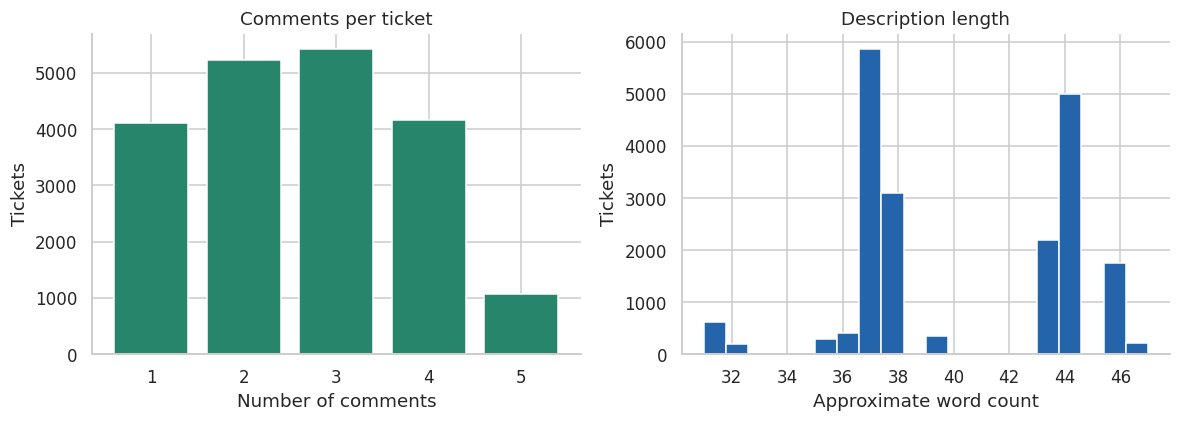

In [14]:
for field, prefix in [("Summary", "summary"), ("Description", "description")]:
    df[prefix + "_chars"] = df[field].fillna("").str.len()
    df[prefix + "_words"] = df[field].fillna("").str.findall(r"\b\w+\b").str.len()
comments = df[["analysis_row_id", "All Comments"]].explode("All Comments").dropna(subset=["All Comments"]).rename(columns={"All Comments": "original_comment"})
comments = comments.reset_index(drop=True)
comments["list_position"] = comments.groupby("analysis_row_id").cumcount() + 1

def split_author(text):
    first, separator, remainder = text.partition(":")
    if separator and re.fullmatch(r"[^\s@:]+@[^\s@:]+", first.strip()):
        return first.strip(), remainder.strip()
    return pd.NA, text.strip()

comments[["author", "text"]] = pd.DataFrame(comments["original_comment"].map(split_author).tolist(), index=comments.index)
comments["words"] = comments["text"].str.findall(r"\b\w+\b").str.len()
comments["normalized_text"] = comments["text"].map(normalize_text)
comments["literal_problem_fixed"] = comments["normalized_text"].eq("problem fixed.")
comments["short_at_most_8_words"] = comments["words"].le(8)
comments["resolution_marker"] = comments["text"].str.contains(r"^resolution(?: recorded)?\s*:", case=False, regex=True)

show_table("text_and_comment_statistics", df[["summary_chars", "description_chars", "description_words", "n_comments"]].describe().rename_axis("statistic").reset_index())
show_table("comment_count_distribution", frequency(df["n_comments"], order=[str(value) for value in sorted(df["n_comments"].unique())]))
phrases = comments["normalized_text"].value_counts().rename_axis("text").reset_index(name="comments")
phrases["comment_pct"] = 100 * phrases["comments"] / len(comments)
show_table("comment_phrases", phrases, limit=TOP_N)

signals = []
for field in ["literal_problem_fixed", "short_at_most_8_words", "resolution_marker"]:
    mask = comments[field]
    affected_tickets = comments.loc[mask, "analysis_row_id"].nunique()
    signals.append({"signal": field, "comments": int(mask.sum()), "comment_pct": 100 * mask.mean(),
                    "tickets_with_at_least_one": affected_tickets, "all_ticket_pct": 100 * affected_tickets / N})
show_table("literal_comment_signals", pd.DataFrame(signals))
print("Total comments:", len(comments), "| Distinct bodies:", comments["normalized_text"].nunique())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
comment_counts = df["n_comments"].value_counts().sort_index()
axes[0].bar(comment_counts.index, comment_counts, color=GREEN)
axes[0].set(title="Comments per ticket", xlabel="Number of comments", ylabel="Tickets")
axes[0].set_xticks(comment_counts.index)
axes[1].hist(df["description_words"], bins=20, color=BLUE, edgecolor="white")
axes[1].set(title="Description length", xlabel="Approximate word count", ylabel="Tickets")
show_figure("08_text_and_comments", fig)

## 15. Signals for reviewing service labels

Literal catalog names are searched only in `Summary` and `Description`. When exactly one
service is mentioned and it differs from the single recorded service, the row is flagged
as a **candidate discrepancy**. This is not semantic classification or an error rate:
a service may be mentioned without being affected, omitted, or referred to by an alias.
No source field is overwritten, and closing comments are not used to infer the original input.
Zero detected discrepancies would not prove that every service label is correct.

In [15]:
service_patterns = {name: re.compile(r"(?<!\w)" + re.escape(name) + r"(?!\w)", flags=re.IGNORECASE) for name in CATALOG}
input_text = df["Summary"].fillna("") + " " + df["Description"].fillna("")
# Cache repeated text, then assign the result to every row.
mentions_by_text = {text: [name for name, pattern in service_patterns.items() if pattern.search(text)] for text in input_text.unique()}
df["literally_mentioned_services"] = input_text.map(mentions_by_text)
df["candidate_service_discrepancy"] = [
    len(mentions) == 1 and len(recorded) == 1 and mentions[0].casefold() != recorded[0].casefold()
    for mentions, recorded in zip(df["literally_mentioned_services"], df["Affected Business or IT Services"])
]
single_mention_mask = df["literally_mentioned_services"].map(len).eq(1) & df["Affected Business or IT Services"].map(len).eq(1)
n_comparable = int(single_mention_mask.sum())
n_discrepancies = int(df["candidate_service_discrepancy"].sum())
show_table("service_mention_summary", pd.DataFrame([
    ("Tickets with one literal mention and one recorded service", n_comparable),
    ("Candidate discrepancies", n_discrepancies),
    ("Tickets without a literal catalog service mention", int(df["literally_mentioned_services"].map(len).eq(0).sum())),
    ("Tickets with multiple literal service mentions", int(df["literally_mentioned_services"].map(len).gt(1).sum())),
], columns=["metric", "tickets"]))
if n_comparable:
    print(f"Candidate discrepancies among comparable tickets: {100 * n_discrepancies / n_comparable:.2f}% ({n_discrepancies:,}/{n_comparable:,}).")
service_review = df.loc[df["candidate_service_discrepancy"], [
    "analysis_row_id", "Summary", "Affected Business or IT Services", "literally_mentioned_services"
]]
show_table("service_review_candidates", service_review, limit=TOP_N)

Candidate discrepancies among comparable tickets: 0.00% (0/20,000).


,metric,tickets
0,Tickets with one literal mention and one recorded service,20000
1,Candidate discrepancies,0
2,Tickets without a literal catalog service mention,0
3,Tickets with multiple literal service mentions,0


,analysis_row_id,Summary,Affected Business or IT Services,literally_mentioned_services


## 16. Findings calculated from the input file

The following cell generates findings from this execution. Counts are recalculated when
you supply another compatible file and run the notebook again.

In [16]:
n_closed = int(df["is_closed"].sum())
n_done_outcome = int(df["Resolution"].eq("done").sum())
n_generic = int(df["Affected Business or IT Services"].map(lambda items: "Emailed Support Tickets" in items).sum())
n_fixed = int(comments["literal_problem_fixed"].sum())
n_templates = int(df["text_template_id"].nunique())
findings = [
    f"**Coverage:** {N:,} tickets, {len(raw.columns)} original fields, and {len(comments):,} comments, without sampling.",
    f"**Work type:** {int(df['Work type'].eq('Incident').sum()):,} incidents and {int(df['Work type'].eq('Service Request').sum()):,} service requests.",
    f"**Status and outcome:** {n_closed:,} tickets have status `done` ({100*n_closed/N:.2f}%). {n_done_outcome:,} have recorded resolution `done` ({100*n_done_outcome/N:.2f}% of all tickets). These are different metrics.",
    f"**Completeness:** {int(df['Resolution'].isna().sum()):,} tickets lack a resolution and {int(df['resolved_at'].isna().sum()):,} lack a valid closure date. Review the status cross-tabulation before treating these as errors.",
    f"**Repetition:** {complete_duplicates:,} complete duplicates beyond the first occurrence and {n_templates:,} normalized title-description templates. Avoid mixing repeated templates across training and evaluation.",
    f"**Generic service:** {n_generic:,} tickets record `Emailed Support Tickets` ({100*n_generic/N:.2f}%). Literal matching detects {n_discrepancies:,} candidate discrepancies; it does not establish label accuracy.",
    f"**Comments:** the exact phrase `Problem fixed.` appears {n_fixed:,} times ({100*n_fixed/len(comments):.2f}% of comments); by itself, it does not explain how to resolve a similar case.",
    "**Priority:** Priority, Urgency, and Impact distributions describe random labels and are not reliable ground truth for training or evaluating real prioritization.",
]
if len(durations):
    findings.insert(4, f"**Time to closure:** median {durations.median():.2f} days and P90 {durations.quantile(.9):.2f} days, across {len(durations):,} closed tickets with valid dates. These are synthetic calendar intervals, not SLA measurements.")
display(Markdown("\n\n".join("- " + finding for finding in findings)))

- **Coverage:** 20,000 tickets, 16 original fields, and 52,845 comments, without sampling.

- **Work type:** 16,000 incidents and 4,000 service requests.

- **Status and outcome:** 16,969 tickets have status `done` (84.84%). 4,236 have recorded resolution `done` (21.18% of all tickets). These are different metrics.

- **Completeness:** 3,031 tickets lack a resolution and 3,031 lack a valid closure date. Review the status cross-tabulation before treating these as errors.

- **Time to closure:** median 10.88 days and P90 18.98 days, across 16,969 closed tickets with valid dates. These are synthetic calendar intervals, not SLA measurements.

- **Repetition:** 0 complete duplicates beyond the first occurrence and 173 normalized title-description templates. Avoid mixing repeated templates across training and evaluation.

- **Generic service:** 5,423 tickets record `Emailed Support Tickets` (27.11%). Literal matching detects 0 candidate discrepancies; it does not establish label accuracy.

- **Comments:** the exact phrase `Problem fixed.` appears 5,851 times (11.07% of comments); by itself, it does not explain how to resolve a similar case.

- **Priority:** Priority, Urgency, and Impact distributions describe random labels and are not reliable ground truth for training or evaluating real prioritization.

## 17. How to use these findings in the hackathon agent

| Purpose | Useful inputs or results | Interpretation |
|---|---|---|
| Understand a new ticket | Summary, Description, Business Entity, recorded service | The service label may be generic or incorrect. |
| Retrieve historical knowledge (RAG) | Similar text, comments, and closing outcome | Check that a case provides actionable steps rather than only “Problem fixed.”. |
| Suggest a team and assignee | Service Team(s), Assignee, observed routes | Validate against the catalog and domain owners; frequency does not establish suitability. |
| Suggest priority | Ticket text and the challenge rules | Obtain reviewed labels; do not learn from the random priorities in this file. |
| Evaluate | Template groups and a reviewed evaluation set | Avoid duplicates and use only information available at prediction time. |
| Measure the future agent | Suggestion, approval, edit, rejection, and timing events | These events are absent here; draft acceptance and time savings cannot be calculated. |

For classification at intake, `Resolution`, `Resolution date`, final status, and later
comments would be **future information**. They can be historical RAG material for other
cases, but should not leak into the same ticket's input during evaluation. An analyst
should review recommendations.

**Further limits:** there are no stable Jira keys, status histories, individual comment
timestamps, SLA rules, working calendars, or documented extraction date. First response,
reopenings, effort, SLA breaches, exact historical backlog, and causal relationships
cannot be reliably calculated from this file alone.

## 18. Export results and verify coverage

Exports include UTF-8 CSV tables, PNG charts, and a manifest recording input hash,
package versions, and limitations. Frequency and template tables are exported **in full**,
even when their displayed previews contain only ten rows.

With `EXPORT_DETAILED_DATA = True`, the notebook additionally writes
`prepared_tickets.csv` and `separated_comments.csv`. Lists are serialized as JSON inside
CSV cells. These are analysis outputs, not validated training labels or a trained model.

In [17]:
# Integrity checks: no tickets have been lost or multiplied during normalization.
assert len(df) == len(records) == N
assert df["analysis_row_id"].is_unique
assert int(templates["tickets"].sum()) == N
assert len(comments) == int(df["n_comments"].sum())
assert len(valid_closed) == int(duration_mask.sum())
assert int(tables["frequency_status"]["tickets"].sum()) == N
assert int(monthly_volume["created"].sum()) == int(df["created_at"].notna().sum())

def serialize_lists(table):
    result = table.copy()
    for column in result.columns:
        if any(isinstance(value, (list, dict)) for value in result[column]):
            result[column] = result[column].map(lambda value: json.dumps(value, ensure_ascii=False) if isinstance(value, (list, dict)) else value)
    return result

manifest = {
    "input_file": DATA_FILE.name,
    "input_sha256": input_sha256,
    "execution_time_utc": datetime.now(timezone.utc).isoformat(),
    "tickets": N,
    "original_fields": raw.columns.tolist(),
    "comments": len(comments),
    "closed_tickets": n_closed,
    "normalized_text_templates": n_templates,
    "additional_complete_duplicates": complete_duplicates,
    "python": platform.python_version(),
    "packages": versions,
    "data_time_zone": "Unspecified; naive dates, without conversion to UTC",
    "synthetic_data": True,
    "all_records_used": True,
    "trains_models": False,
    "sources": [DATA_FILE.name, "challenge_guidance.md (supplied challenge README)"],
    "limitations": [
        "Priority, Urgency, and Impact are random according to the challenge guidance.",
        "Recorded services and historical routes are not ground truth.",
        "Time to closure uses calendar days and only closed tickets with valid dates.",
        "No Jira keys, extraction date, SLA rules, status history, or comment timestamps.",
        "The separate 20-ticket challenge file is not included.",
    ],
}
if EXPORT:
    (OUTPUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
    for name, table in tables.items():
        serialize_lists(table).to_csv(OUTPUT_DIR / "tables" / f"{name}.csv", index=False, encoding="utf-8-sig")
    if EXPORT_DETAILED_DATA:
        serialize_lists(df).to_csv(OUTPUT_DIR / "prepared_tickets.csv", index=False, encoding="utf-8-sig")
        comments.to_csv(OUTPUT_DIR / "separated_comments.csv", index=False, encoding="utf-8-sig")
    (OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"Saved {len(tables)} complete tables and 8 charts in this analysis folder's results directory.")
else:
    print("Export disabled. Results remain available in the notebook outputs.")
print(f"Validation complete: {N:,} tickets and {len(comments):,} comments processed.")

Saved 37 complete tables and 8 charts in this analysis folder's results directory.
Validation complete: 20,000 tickets and 52,845 comments processed.
